<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    Séries Temporais para Projetos de Data Science
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Projeto 1 - Modelagem de Séries Temporais para<br />Prever Usuários Ativos em um<br />Web Site ao Longo do Tempo - Etapa 02
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento,<br \> [-] Custo,<br \> [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>📌 Objetivo</strong></font>

<font size="3" color='#66666'>

- Este Projeto demonstra na prática o processo de modelagem de séries temporais, começando do mais absoluto zero e caminhando passo a passo até as tarefas mais avançadas.
- **Nosso trabalho é construir um modelo capaz de prever o volume de usuários ativos em um web site ao longo do tempo.**
- Usaremos dados fictícios que representam informação real.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Instalando e Carregando os Pacotes</strong></font>

<font size="3" color='#66666'></font></div>

In [1]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
# !pip install -q -U watermark

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Importando Bibliotecas</strong></font>

<font size="3" color='#66666'></font></div>

In [2]:
# Imports para manipulação de dados
import matplotlib as m

# Imports para visualização de dados
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Imports para análise e modelagem de séries temporais
import statsmodels.api as sm
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Formatação para os gráficos e tabelas</strong></font>

<font size="3" color='#66666'></font></div>

In [3]:
# Formatação para os gráficos e tabelas
plt.style.use('ggplot')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

<div style="background-color:#f3f2ee">
    
<font size="4" color='#FF5733'><strong>📚 Formatando as labels dos gráficos</strong></font>

<font size="3" color='#66666'></font></div>

In [4]:
# Formatando os labels dos gráficos
m.rcParams['axes.labelsize'] = 12
m.rcParams['xtick.labelsize'] = 10
m.rcParams['ytick.labelsize'] = 10
m.rcParams['text.color'] = 'k'

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "robertossoares-lflnglrnng" 

Author: robertossoares-lflnglrnng



<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>⚙️ 1. Carregando e Explorando os Dados</strong></font>

<font size="3" color='#66666'></font></div>

In [29]:
# Carrega os dados
dados = pd.read_csv('../data/raw/dataset.csv', engine='pyarrow', header = None)

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Perceba que são duas colunas.
    - Esses dados representam **uma série univariada**, pois temos uma variável aleatória (usuarios_ativos) e a data, que representa o índice da série.
    - Veja que a série é mensal.
- Vamos ajustar o nome de cada coluna.

---    
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>⚙️ 2. Processamento e Visualização dos Dados</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Ajustando o nome de cada coluna:</strong></font>

<font size="3" color='#66666'></font></div>

In [30]:
# Ajustando o nome de cada coluna
dados.columns = ['mes', 'usuarios_ativos']

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Convertendo a coluna data de object para datetime:</strong></font>

<font size="2" color='#66666'></font></div>

In [31]:
# Convertendo a coluna data de object para datetime  
dados['mes'] = pd.to_datetime(dados['mes'], format = '%Y-%m')

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Vamos transformar a coluna de data no índice do conjunto de dados:</strong></font>

<font size="2" color='#66666'></font></div>

In [32]:
# Vamos transformar a coluna de data no índice do conjunto de dados. 
# Isso vai facilitar nosso trabalho mais a frente.
dados_serie = dados.set_index('mes')

In [33]:
dados_serie.head()

,usuarios_ativos
mes,
2013-01-01,110
2013-02-01,121
2013-03-01,135
2013-04-01,127
2013-05-01,128


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- ***Transformamos a coluna de data no índice do conjunto de dados.***     
- Agora sim podemos chamar esse conjunto de dados de série temporal.
    - Vamos visualizar o índice:

---    
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 2.1. Plot da Série Temporal - Primeira Análise de Tendência</strong></font>

<font size="3" color='#66666'></font></div>

In [11]:
type(dados_serie)

pandas.core.frame.DataFrame

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Plot da Série Temporal - aqui já observamos algumas tendências</strong></font>

<font size="2" color='#66666'></font></div>

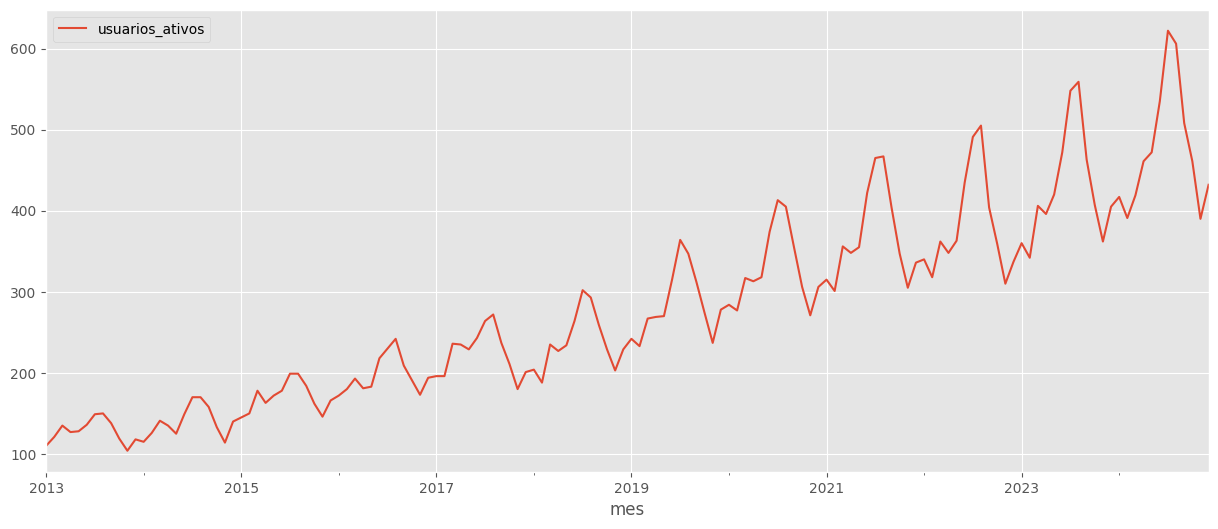

In [12]:
# Plot da Série Temporal - aqui já observamos algumas tendências
dados_serie.plot(figsize = (15, 6))
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

> - O gráfico acima mostra **2 componentes da série**: Sazonalidade e Tendência. 
>    - **Sazonalidade:** O fenômeno se repete em períodos fixos.
>    - **Tendência:** Ao longo do tempo, a série segue uma tendência de crescimento.

> - Outro aspecto a considerar é o **comportamento cíclico**.
>    - Isso acontece quando o padrão de subida e descida da série não ocorre em intervalos fixos baseados em calendário.
>    - Deve-se tomar cuidado para **não confundir** efeito **"cíclico" com** efeito **"sazonal"**.
>    - Mas, como diferenciar um padrão "cíclico" versus "sazonal"?
>        - Se os padrões não tiverem frequências fixas baseadas em calendário, será cíclico.
>            - Porque, diferentemente da sazonalidade, os efeitos cíclicos são tipicamente influenciados pelos negócios e outros fatores socioeconômicos.    

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="5" color='#CC403E'><strong>⚙️ 3. Propriedades Estatísticas de Séries Temporais</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

- Antes de iniciar qualquer modelagem preditiva em séries temporais é necessário verificar se essas propriedades estatísticas são constantes na série temporal:
    - **Estacionariedade**: **a série temporal deve ser estacionária**, ou seja, suas **características estatísticas, como média e variância, não mudam ao longo do tempo**.
    - **Não-autocorrelação**: as observações da série temporal **não devem ser fortemente correlacionadas** com observações anteriores.
    - **Normalidade**: é frequentemente pressuposto que as observações da série temporal são **distribuídas normalmente** (seguem uma distribuição normal).

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

- **Compreendendo os Conceitos de Distribuição Normal, Média e Variância**

>Vamos explorar cada um desses conceitos:
>    - **Distribuição Normal (ou Gaussiana)**
>        - A distribuição normal é uma das distribuições de probabilidade mais importantes e comuns em estatística.
>        - É caracterizada por sua forma de **sino e é simétrica** em relação à sua média.
>    - Características:
>        - **Simetria:** A curva é simétrica ao redor da média, o que significa que a metade da população está à esquerda da média e a outra metade à direita.
>        - **Pontos de inflexão:** A curva tem pontos de inflexão onde a mudança da concavidade ocorre, localizados a um desvio padrão à esquerda e à direita da média.
>        - **Área sob a curva:** A área total sob a curva de distribuição normal é igual a 1, o que representa a totalidade da probabilidade.
>        - **Aplicações:** É utilizada para modelar fenômenos naturais, notas de testes, erros de medição, entre outros.
      
>**Média**
>    - A **média é uma medida de tendência central** que descreve o valor "central" ou "típico" de um conjunto de dados.
>    - É calculada somando todos os valores do conjunto de dados e dividindo pelo número total de valores.
>    - Serve como um ponto de referência para comparar os valores individuais do conjunto de dados.
    
>**Variância**
>    - A variância é uma **medida de dispersão** que **indica o quão espalhados estão os valores em um conjunto de dados em relação à média**.
>    - Quanto maior a variância, mais distantes estão os valores da média.
>    - ***Uma variância baixa indica que os dados estão agrupados perto da média, enquanto uma variância alta indica que os dados estão mais espalhados e distantes da média.***
    
>- A distribuição normal utiliza a **média e a variância como parâmetros fundamentais** para sua definição, onde a média determina o centro da distribuição e a variância determina o quão achatada ou estreita é a curva.
>- Esses conceitos estão intrinsecamente ligados e são essenciais para a análise de dados e a tomada de decisões baseadas em evidências estatísticas.

---
</font></div>

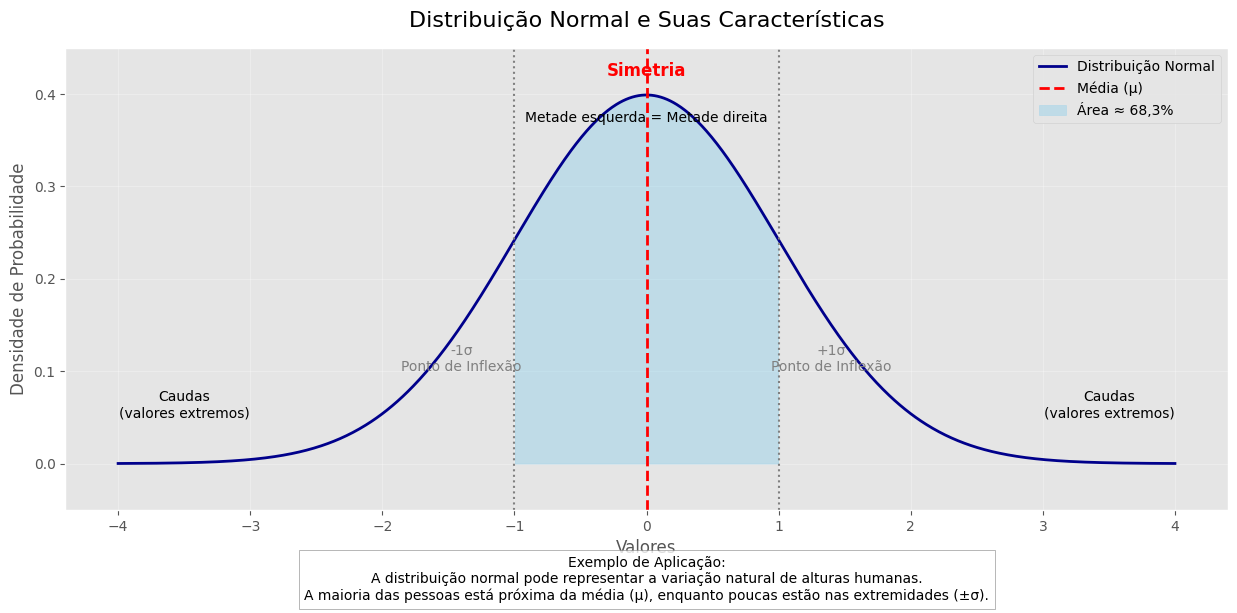

In [13]:
#import numpy as np
#import matplotlib.pyplot as plt
#from scipy.stats import norm
# -----------------------------
# Parâmetros da distribuição
# -----------------------------
mu, sigma = 0, 1  # média e desvio padrão

# Eixo x e densidade (PDF)
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, mu, sigma)

# -----------------------------
# Criação do gráfico
# -----------------------------
plt.figure(figsize=(15,6))
plt.plot(x, y, color='darkblue', lw=2, label='Distribuição Normal')

# Linha da média
plt.axvline(mu, color='red', linestyle='--', lw=2, label='Média (μ)')

# Pontos de inflexão (μ ± σ)
plt.axvline(mu - sigma, color='gray', linestyle=':', lw=1.5)
plt.axvline(mu + sigma, color='gray', linestyle=':', lw=1.5)
plt.text(mu - sigma - 0.4, 0.1, '-1σ\nPonto de Inflexão', color='gray', ha='center')
plt.text(mu + sigma + 0.4, 0.1, '+1σ\nPonto de Inflexão', color='gray', ha='center')

# Área sob a curva (entre -1σ e +1σ)
plt.fill_between(x, 0, y, where=(x > mu - sigma) & (x < mu + sigma), color='skyblue', alpha=0.4, label='Área ≈ 68,3%')

# -----------------------------
# Anotações de características
# -----------------------------
plt.text(mu, 0.42, 'Simetria', fontsize=12, color='red', ha='center', fontweight='bold')
plt.text(mu, 0.37, 'Metade esquerda = Metade direita', fontsize=10, color='black', ha='center')

plt.text(-3.5, 0.05, 'Caudas\n(valores extremos)', fontsize=10, color='black', ha='center')
plt.text(3.5, 0.05, 'Caudas\n(valores extremos)', fontsize=10, color='black', ha='center')

# -----------------------------
# Exemplo de aplicação
# -----------------------------
plt.text(0, -0.10,
         'Exemplo de Aplicação:\n'
         'A distribuição normal pode representar a variação natural de alturas humanas.\n'
         'A maioria das pessoas está próxima da média (μ), enquanto poucas estão nas extremidades (±σ).',
         fontsize=10, ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# -----------------------------
# Configuração final
# -----------------------------
plt.title('Distribuição Normal e Suas Características', fontsize=16, pad=15)
plt.xlabel('Valores')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.05, 0.45)
plt.show()


<div align="left" style="background-color:#f3f2ee">

<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

| Conceito                                     | Representação visual                                  | Explicação                                                                    |
|----------------------------------------------|-------------------------------------------------------|-------------------------------------------------------------------------------| 
| Simetria                                     | A curva é espelhada em relação à média (μ)            | Metade dos valores está à esquerda e metade à direita                         |
| Pontos de Inflexão (μ ± σ)                   | Linhas pontilhadas cinzas                             | Onde a concavidade da curva muda de côncava para convexa                      | 
| Área sob a curva                             | Faixa azul clara entre -1σ e +1σ                      | Representa ~68,3% dos valores observados                                      | 
| Exemplo prático                              | Estudo sobre altura de uma população                  | Altura de pessoas, erros de medição, notas de exames, etc.                    | 

---
</font></div>


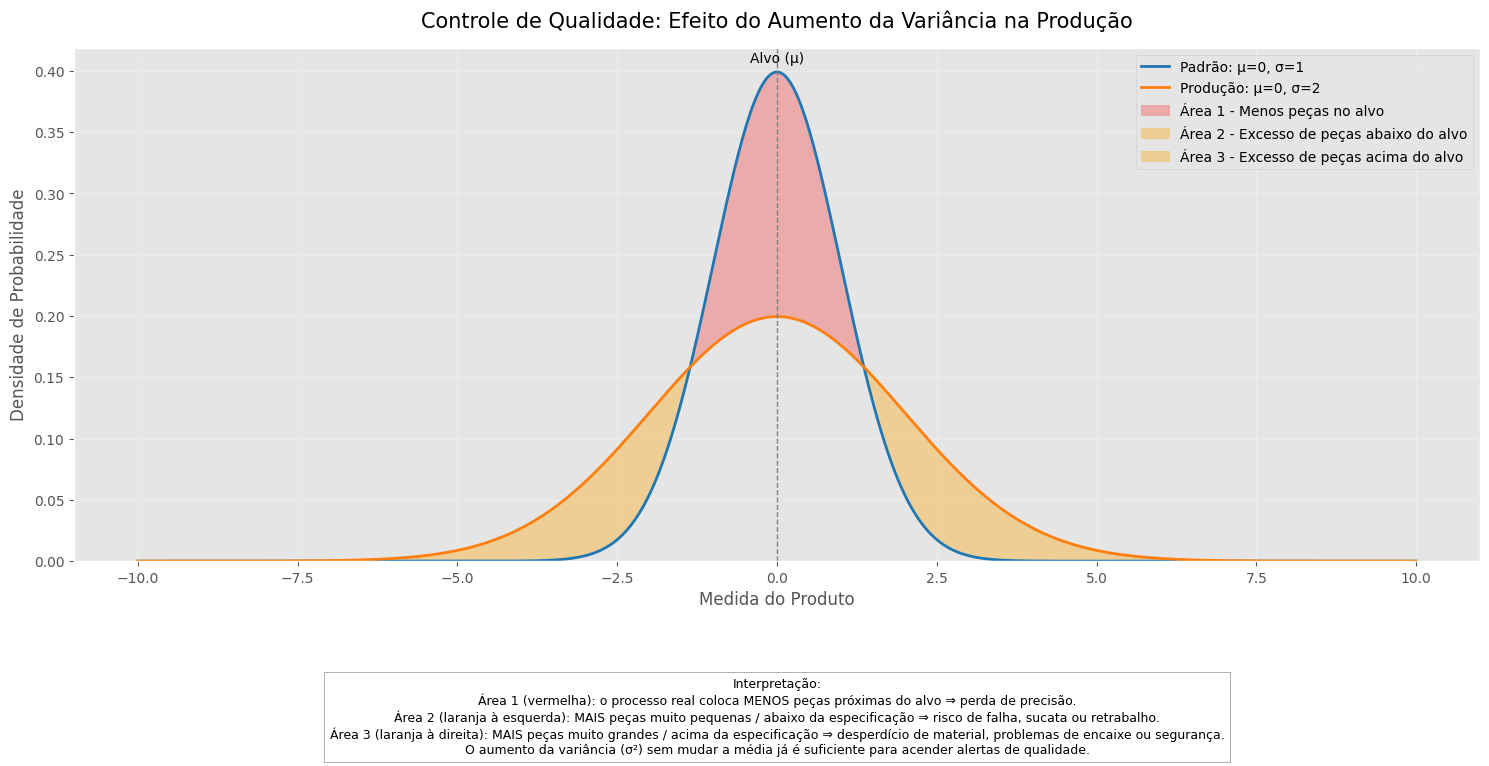

In [14]:
##import numpy as np
##import matplotlib.pyplot as plt
##from scipy.stats import norm
# -----------------------------
# Distribuições
# -----------------------------
mu_ref, sigma_ref = 0, 1   # Processo alvo (padrão)
mu_proc, sigma_proc = 0, 2 # Processo real (mais variável)

x = np.linspace(-10, 10, 2000)
y_ref = norm.pdf(x, mu_ref, sigma_ref)
y_proc = norm.pdf(x, mu_proc, sigma_proc)

# -----------------------------
# Encontra pontos de interseção entre padrão e processo
# -----------------------------
diff = y_ref - y_proc
idx = np.where(np.diff(np.sign(diff)) != 0)[0]

# Garantindo dois pontos de interseção (simétricos nesse caso)
x1 = x[idx[0]]
x2 = x[idx[1]]

# -----------------------------
# Figura
# -----------------------------
plt.figure(figsize=(15,8))

# Curvas
plt.plot(x, y_ref, label='Padrão: μ=0, σ=1', color='tab:blue', lw=2)
plt.plot(x, y_proc, label='Produção: μ=0, σ=2', color='tab:orange', lw=2)

# Linha na média alvo
plt.axvline(mu_ref, color='gray', linestyle='--', lw=1)
plt.text(mu_ref, max(y_ref)*1.02, 'Alvo (μ)', ha='center', fontsize=10)

# -----------------------------
# ÁREA 1: Centro (entre x1 e x2)
# Aqui o processo real tem MENOS densidade que o padrão.
# Significa menos peças exatamente próximas do alvo.
# -----------------------------
plt.fill_between(
    x, y_ref, y_proc,
    where=(x >= x1) & (x <= x2) & (y_ref > y_proc),
    color='red', alpha=0.25,
    label='Área 1 - Menos peças no alvo'
)

# -----------------------------
# ÁREA 2: Cauda Esquerda (x < x1)
# Processo real tem MAIS densidade que o padrão.
# Mais peças muito abaixo da especificação.
# -----------------------------
plt.fill_between(
    x, y_proc, y_ref,
    where=(x < x1) & (y_proc > y_ref),
    color='orange', alpha=0.35,
    label='Área 2 - Excesso de peças abaixo do alvo'
)

# -----------------------------
# ÁREA 3: Cauda Direita (x > x2)
# Processo real tem MAIS densidade que o padrão.
# Mais peças muito acima da especificação.
# -----------------------------
plt.fill_between(
    x, y_proc, y_ref,
    where=(x > x2) & (y_proc > y_ref),
    color='orange', alpha=0.35,
    label='Área 3 - Excesso de peças acima do alvo'
)

# -----------------------------
# Ajustes visuais
# -----------------------------
plt.title('Controle de Qualidade: Efeito do Aumento da Variância na Produção', fontsize=15, pad=15)
plt.xlabel('Medida do Produto')
plt.ylabel('Densidade de Probabilidade')
plt.grid(alpha=0.3)
plt.legend(loc='upper right')
plt.ylim(bottom=0)

# Texto explicativo
plt.text(
    0, -0.095,
    (
        "Interpretação:\n"
        "Área 1 (vermelha): o processo real coloca MENOS peças próximas do alvo ⇒ perda de precisão.\n"
        "Área 2 (laranja à esquerda): MAIS peças muito pequenas / abaixo da especificação ⇒ risco de falha, sucata ou retrabalho.\n"
        "Área 3 (laranja à direita): MAIS peças muito grandes / acima da especificação ⇒ desperdício de material, problemas de encaixe ou segurança.\n"
        "O aumento da variância (σ²) sem mudar a média já é suficiente para acender alertas de qualidade."
    ),
    ha='center', va='top', fontsize=9,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray')
)

plt.tight_layout()
plt.show()


<div align="left" style="background-color:#f3f2ee">

<font size="3" color='#FF5733'><strong>🔍 Leitura dos três fenômenos (didático para portfólio):</strong></font>

<font size="3" color='#66666'>

> Perda de precisão (Área 1)
>    - O pico da produção real é mais baixo que o do padrão.
>    - Menos peças saem exatamente dentro da faixa “ideal”.
>    - Sinal de processo desajustado ou instável — mesmo que ainda “pareça” centrado.

> Risco por peças abaixo da especificação (Área 2)
>    - Mais probabilidade no lado esquerdo extremo.
>        - Ex.: parafusos finos demais, frascos com menos volume, resistência mecânica insuficiente.
>    - Impacto: falha de performance, devolução, perda de confiabilidade.

> Risco por peças acima da especificação (Área 3)
>    - Mais probabilidade no lado direito extremo.
>        - Ex.: diâmetro grande demais, excesso de material, encaixe difícil, sobrecarga.
>    - Impacto: custo maior, problemas de montagem, risco operacional.

---
</font></div>

Cp  = 0.50
Cpk = 0.50


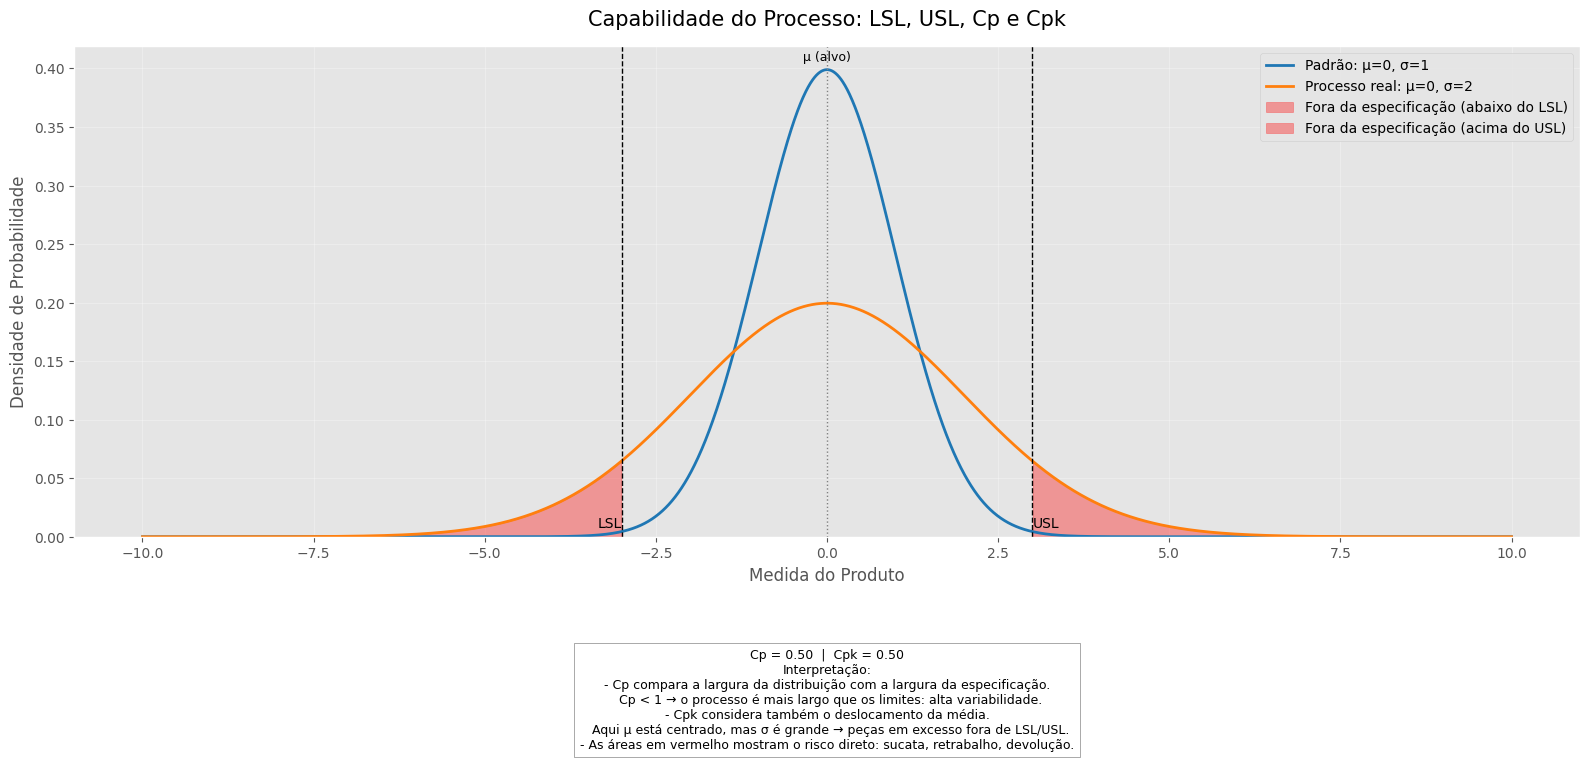

In [15]:
#import numpy as np
#import matplotlib.pyplot as plt
#from scipy.stats import norm
# -----------------------------
# Parâmetros
# -----------------------------
mu_ref, sigma_ref = 0, 1    # Processo alvo (referência)
mu_proc, sigma_proc = 0, 2  # Processo real (mais disperso)

LSL, USL = -3, 3            # Limites de Especificação

# Eixo x
x = np.linspace(-10, 10, 3000)

# Densidades
y_ref = norm.pdf(x, mu_ref, sigma_ref)
y_proc = norm.pdf(x, mu_proc, sigma_proc)

# -----------------------------
# Cálculo de Cp e Cpk para o processo real
# -----------------------------
# Cp = (USL - LSL) / (6 * sigma)
# Cpk = min( (USL - mu)/(3*sigma), (mu - LSL)/(3*sigma) )

Cp = (USL - LSL) / (6 * sigma_proc)
Cpk = min((USL - mu_proc) / (3 * sigma_proc),
          (mu_proc - LSL) / (3 * sigma_proc))

print(f'Cp  = {Cp:.2f}')
print(f'Cpk = {Cpk:.2f}')

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16,8))

# Curva padrão (alvo)
plt.plot(x, y_ref, color='tab:blue', lw=2, label='Padrão: μ=0, σ=1')

# Curva processo real
plt.plot(x, y_proc, color='tab:orange', lw=2, label='Processo real: μ=0, σ=2')

# Limites de especificação
plt.axvline(LSL, color='black', linestyle='--', lw=1)
plt.axvline(USL, color='black', linestyle='--', lw=1)
plt.text(LSL, 0.005, 'LSL', ha='right', va='bottom')
plt.text(USL, 0.005, 'USL', ha='left', va='bottom')

# Linha da média alvo
plt.axvline(mu_proc, color='gray', linestyle=':', lw=1)
plt.text(mu_proc, max(y_ref)*1.02, 'μ (alvo)', ha='center', fontsize=9)

# -----------------------------
# Área fora da especificação (processo real)
# -----------------------------
# x < LSL
plt.fill_between(
    x, 0, y_proc,
    where=(x < LSL),
    color='red', alpha=0.35,
    label='Fora da especificação (abaixo do LSL)'
)

# x > USL
plt.fill_between(
    x, 0, y_proc,
    where=(x > USL),
    color='red', alpha=0.35,
    label='Fora da especificação (acima do USL)'
)

# -----------------------------
# Configurações
# -----------------------------
plt.title('Capabilidade do Processo: LSL, USL, Cp e Cpk', fontsize=15, pad=15)
plt.xlabel('Medida do Produto')
plt.ylabel('Densidade de Probabilidade')
plt.grid(alpha=0.3)
plt.legend(loc='upper right')
plt.ylim(bottom=0)

# Texto explicativo
texto = (
    f"Cp = {Cp:.2f}  |  Cpk = {Cpk:.2f}\n"
    "Interpretação:\n"
    "- Cp compara a largura da distribuição com a largura da especificação.\n"
    "  Cp < 1 → o processo é mais largo que os limites: alta variabilidade.\n"
    "- Cpk considera também o deslocamento da média.\n"
    "  Aqui μ está centrado, mas σ é grande → peças em excesso fora de LSL/USL.\n"
    "- As áreas em vermelho mostram o risco direto: sucata, retrabalho, devolução."
)

plt.text(
    0, -0.095,
    texto,
    ha='center', va='top', fontsize=9,
    bbox=dict(facecolor='white', alpha=0.95, edgecolor='gray')
)

plt.tight_layout()
plt.show()


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 3.1. Plot das Rolling Statistics (Estatísticas Móveis)</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

- **As estatísticas móveis, também conhecidas como estatísticas rolantes ou estatísticas deslizantes, são uma técnica usada na análise de séries temporais para calcular estatísticas, como média, mediana, soma, variância e desvio padrão, em uma janela deslizante de tamanho fixo ao longo da série.**
    - A ideia é analisar e entender as mudanças nas estatísticas locais ao longo do tempo, o que pode ajudar a identificar **tendências, sazonalidade, pontos de mudança e outras características** dos dados.
- Para calcular estatísticas móveis, você define uma **janela de tamanho 'n'** (onde n é um número inteiro) e move a janela ao longo da série temporal, calculando a estatística desejada para cada subconjunto de dados dentro da janela.
    - A janela avança uma observação de cada vez e o cálculo é repetido até que a janela alcance o final da série.
- *Por exemplo, para calcular a média móvel de uma série temporal, você seleciona uma janela de tamanho n e calcula a média dos valores dentro da janela.*
    - *Em seguida, a janela é deslocada uma posição à frente e a média é recalculada para os novos valores na janela.*
        - *Esse processo é repetido até que a janela atinja o final da série temporal.*

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>🚀 Primeiro, vamos checar se as estatísticas móveis são ou não constantes ao longo da série temporal.</strong></font>

<font size="2" color='#66666'></font></div>

In [16]:
type(dados)

pandas.core.frame.DataFrame

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- O **rolling() método do Pandas**
    - Oferece funcionalidade para realizar cálculos de janela deslizante em objetos Series ou DataFrame.
    - Isso é particularmente **útil para análise de séries temporais** e processamento de sinais, onde é necessário calcular estatísticas sobre um subconjunto móvel de dados.
    - **Conceitos-chave:**
        - **Janela deslizante**: Um intervalo ou subconjunto de dados de tamanho fixo que se move sequencialmente através de um conjunto de dados maior.
        - **Tamanho da janela**: O número de pontos de dados ou o período de tempo incluído em cada janela móvel. Isso pode ser especificado como um número inteiro (número de linhas)
            - ou um deslocamento baseado em tempo (por exemplo, '7D' para 7 dias).
        - **Operações de laminação**: Após definir a janela, diversas operações estatísticas ou personalizadas podem ser aplicadas a cada janela, tais como:
            - mean()  Calcula a média móvel.
            - sum()   Calcula a soma acumulada.
            - min()   Calcula o mínimo móvel.
            - max()   Calcula o máximo acumulado.
            - std()   Calcula o desvio padrão móvel.
            - apply() Permite aplicar funções personalizadas a cada janela. 
- Uso básico:
    - Para usar rolling(), primeiro você o chama em uma Series ou DataFrame, especificando o tamanho da janela.
    - Em seguida, você encadeia uma função de agregação desejada.

---
</font></div>

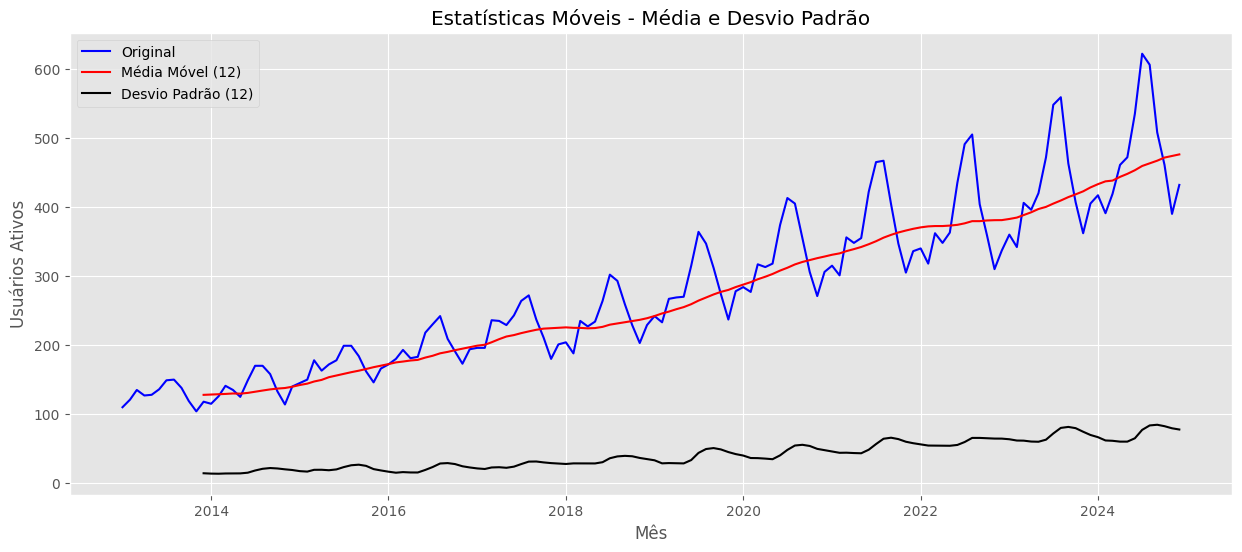

In [17]:
# Estatísticas móveis
window = 12
rolmean = dados['usuarios_ativos'].rolling(window=window).mean()  # estatística móvel - média
rolstd  = dados['usuarios_ativos'].rolling(window=window).std()   # estatística móvel - desvio padrão

# BLOCO 1 - GRÁFICO ESTÁTICO
fig1, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(dados['mes'], dados['usuarios_ativos'], color='blue',  label='Original')
ax1.plot(dados['mes'], rolmean,                  color='red',   label='Média Móvel (12)')
ax1.plot(dados['mes'], rolstd,                   color='black', label='Desvio Padrão (12)')

ax1.set_title('Estatísticas Móveis - Média e Desvio Padrão')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Usuários Ativos')
ax1.legend(loc='best')

plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

- Análise:
    - Observamos que a **média móvel e o desvio padrão não são constantes em relação ao tempo** (tendência crescente).
        - A série **não é**, portanto, **estacionária**.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 3.2. Plots da Função de Autocorrelação (ACF) e Função de Autocorrelação Parcial (PACF)</strong></font>

<font size="3" color='#66666'></font></div>

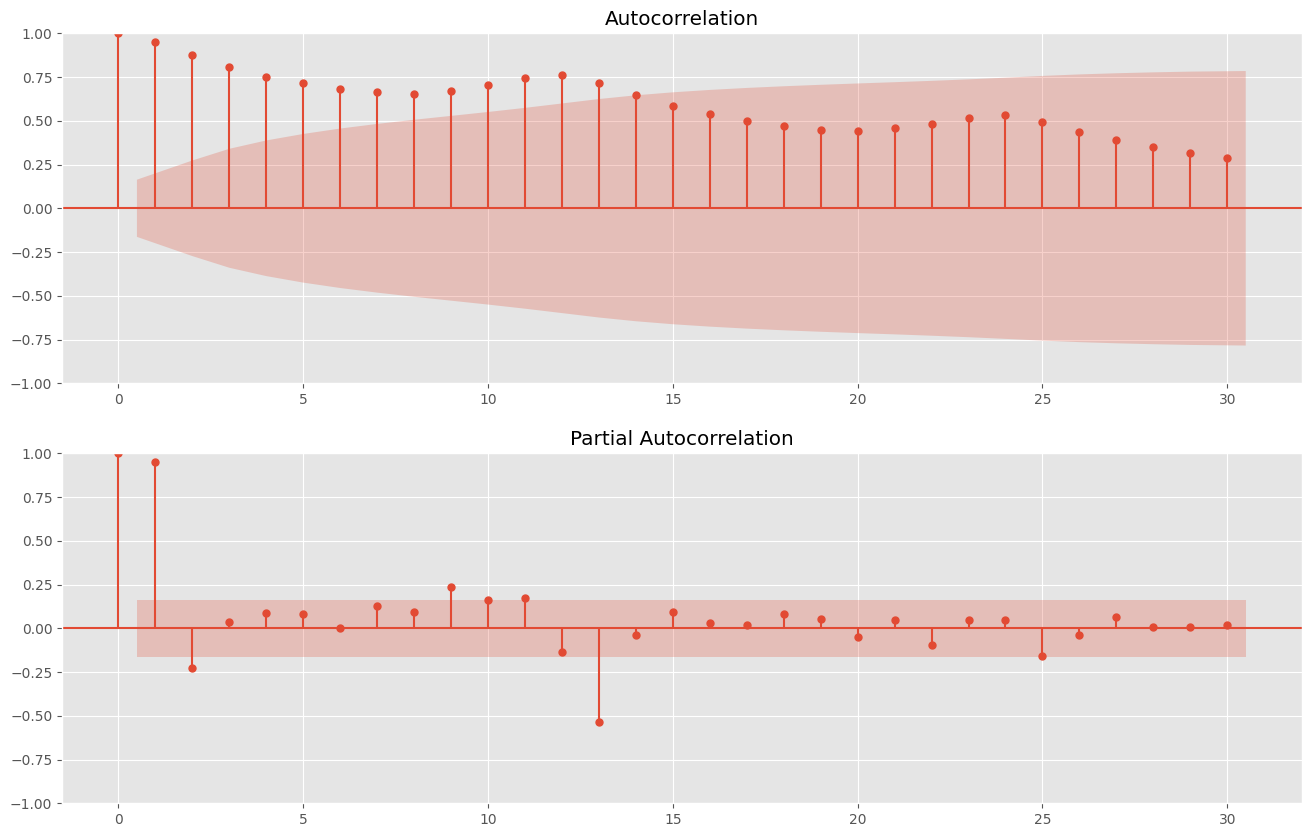

In [18]:
# Plots
plt.rcParams.update({'figure.figsize': (16,10)})

# Plot do gráfico ACF
plt.subplot(211)
plot_acf(dados_serie.usuarios_ativos, ax = plt.gca(), lags = 30)

# Plot do gráfico PACF
plt.subplot(212)
plot_pacf(dados_serie.usuarios_ativos, ax = plt.gca(), lags = 30, method = 'ywm')
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

>- **Interpretação dos Gráficos**:
>    - No gráfico, **o eixo vertical indica a autocorrelação e o horizontal a defasagem**. 
>    - A **área sombreada indica onde é significativamente diferente de zero**.
>        - Como é possível ver na imagem, temos diversos valores ACF (barras verticais) acima do limite da área sombreada.
>        - Nesses casos, a autocorrelação é diferente de zero, indicando que a série não é aleatória – conforme o esperado.
>    - Algumas barras verticais estão dentro do limite da área sombreada.
>        - Ou seja, **a autocorrelação entre a série com alguns de seus lags é igual a zero, indicando que não há correlação**.

>- Em termos simples: a área sombreada aponta a significância.
>    - Se ultrapassada é porque tem correlação.

>- Cada barra no gráfico ACF representa o nível de correlação entre a série e seus atrasos em ordem cronológica.
>    - A área sombreada indica se o nível de correlação entre a série e cada atraso é significativo ou não. 

>- O PACF é apenas uma visualização parcial do ACF.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

>- Análise:
>    - **Se a série temporal for estacionária, os gráficos do ACF / PACF mostrarão uma "queda rápida na correlação" após um pequeno atraso entre os pontos.**
>        - ***Não é o caso em nossos gráficos.***
>            - ***A queda lenta (redução do tamanho das barras) indica que essa série não é estacionária.***
>- Os dados da nossa série **não são estacionários**, pois um número alto de **observações anteriores está correlacionado com valores futuros**.
>    - Intervalos de confiança são desenhados na área sombreada.
>        - Por padrão, isso é definido como um intervalo de confiança de 95%, sugerindo que os valores de correlação fora desta área provavelmente são uma correlação e não um acaso estatístico.
>- Teremos que transformar essa série em estacionária antes de criar um modelo preditivo. Veremos isso mais adiante.

>- Aqui estão os principais aspectos que você busca ao interpretar um gráfico ACF:
>    - **1. Dependência Temporal**
>        - ACF mede a correlação entre observações de uma série temporal separadas por diferentes lags (defasagens).
>        - Um pico significativo em um lag específico indica que os valores na série temporal estão correlacionados com seus valores em lags anteriores.
>        - Isso é fundamental para identificar se a série possui dependência temporal.
>    - **2. Identificação de Sazonalidade**
>        - Se o gráfico ACF mostra picos regulares em intervalos específicos, isso pode indicar a presença de sazonalidade na série.
>        - Por exemplo, um pico significativo a cada 12 lags em dados mensais pode sugerir um padrão sazonal anual.
>    - **3. Determinação da Ordem de Modelos ARIMA**
>        - Para modelos ARIMA (AutoRegressive Integrated Moving Average), a análise do gráfico ACF (junto com o PACF - Função de Autocorrelação Parcial) pode 
>            - ajudar a determinar a ordem dos componentes AR (autoregressivos) e MA (médias móveis).
>        - Por exemplo, um declínio gradual no ACF sugere componentes AR, enquanto um corte brusco após um lag específico sugere componentes MA.
>    - **4. Estacionariedade**
>        - Uma série temporal é estacionária se sua média e variância permanecem constantes ao longo do tempo.
>        - No gráfico ACF, uma diminuição muito lenta ou a ausência de diminuição nas autocorrelações pode indicar que a série não é estacionária.
>        - A estacionariedade é muitas vezes um pré-requisito para a modelagem eficaz de séries temporais.
>    - **5. Ruído Branco**
>        - Se todas as autocorrelações são insignificantes (ou seja, próximas de zero para todos os lags), a série pode ser um ruído branco, indicando que os valores são independentes e identicamente distribuídos.
>        - Isso significa que a série não possui padrões previsíveis ou dependência temporal significativa.

---
</font></div>

In [19]:
dados_serie

,usuarios_ativos
mes,
2013-01-01,110
2013-02-01,121
2013-03-01,135
2013-04-01,127
2013-05-01,128
...,...
2024-08-01,606
2024-09-01,508
2024-10-01,461


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="3" color='#66666'>

- **O Que é Um Teste de Hipóteses?**

>- Um teste de hipóteses é um procedimento estatístico que permite tomar decisões sobre uma população com base em dados amostrais.
>- Esse método é utilizado para avaliar duas hipóteses mutuamente exclusivas sobre uma população:
>    - a hipótese nula (H0) e
>    - a hipótese alternativa (H1 ou Ha).
  
>- **Hipótese Nula (H0):** É uma afirmação de que não há diferença ou efeito, ou que um parâmetro de interesse é igual a um valor específico.
>    - Por exemplo, H0 pode afirmar que a média de uma população é igual a um valor conhecido.
    
>- **Hipótese Alternativa (H1 ou Ha)**: É a hipótese que se quer provar ou que se acredita ser verdadeira.
>    - Contrapõe-se à hipótese nula e geralmente é formulada para indicar a presença de um efeito ou diferença.
>    - Por exemplo, Ha pode afirmar que a média de uma população é diferente de um valor conhecido.
    
>- O teste de hipóteses é realizado seguindo estes passos básicos:
>    - **Formulação das hipóteses**: Definem-se a hipótese nula e a hipótese alternativa.
>    - **Escolha do nível de significância (α)**: O nível de significância representa a probabilidade de rejeitar a hipótese nula quando ela é verdadeira.
>        - **Valores comuns são 0,05 (5%) ou 0,01 (1%)**.
>    - **Seleção do teste estatístico**: O teste a ser utilizado depende da natureza dos dados e do objetivo do estudo.
>        - Exemplos incluem o teste t, teste de qui-quadrado, ANOVA, entre outros.
>    - **Cálculo do teste estatístico e valor-p**: O teste estatístico é calculado a partir dos dados da amostra.
>        - O valor-p é a probabilidade de obter um resultado tão extremo quanto o Observado (ou mais) sob a hipótese nula.
>    - **Decisão**: Compara-se o valor-p com o nível de significância α.
>        - Se o p-valor for menor que α, rejeita-se a hipótese nula em favor da hipótese alternativa.
>        - Caso contrário, não se rejeita a hipótese nula.
      
>- Este método é amplamente usado em diversas áreas do conhecimento para testar teorias, comparar grupos, verificar a eficácia de tratamentos e muito mais,
>    - sempre com o objetivo de tomar decisões informadas com base em evidências empíricas.
>- E usamos testes de hipóteses amplamente na análise e modelagem de séries temporais.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 3.3. Teste Estatístico Dickey-Fuller Aumentado</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- O Teste Estatístico Dickey-Fuller Aumentado (ADF, do inglês Augmented Dickey-Fuller) é uma versão ampliada do teste de Dickey-Fuller, usado para verificar a presença de raiz unitária em uma série temporal, ou seja, para testar a estacionariedade da série.
- Uma série temporal é considerada estacionária quando suas propriedades estatísticas, como média e variância, são constantes ao longo do tempo.
    - A presença de uma raiz unitária indica que a série é não estacionária, o que pode afetar a análise e a modelagem dessa série.
- O teste ADF é particularmente útil porque pode acomodar uma estrutura de autocorrelação mais complexa em comparação com o teste Dickey-Fuller original.
    - Isso é feito incluindo termos de defasagem da variável dependente (lags) na equação de teste para controlar a autocorrelação serial.
- Estas são as hipóteses do teste:
    - Hipótese Nula (H0): A série possui uma raiz unitária (γ=0), indicando não estacionariedade.
    - Hipótese Alternativa (H1): A série não possui raiz unitária (γ<0 para o caso unicaudal), indicando estacionariedade.
- Ou, de forma mais simples:
    - Hipótese Nula (H0): A série temporal não é estacionária.
    - Hipótese Alternativa (H1) - A série temporal é estacionária.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- A **adfuller função em Python**
>    - Faz parte da statsmodels.tsa.stattools biblioteca, realiza o teste de Dickey-Fuller Aumentado (ADF) para estacionariedade em uma série temporal.

>- Propósito:
>    - O teste ADF determina se uma série temporal possui uma raiz unitária, indicando não estacionariedade.
>    - A estacionariedade é uma premissa crucial para muitos modelos de séries temporais, como o ARIMA.

>- Hipóteses:
>    - Hipótese nula (H0): A série temporal possui uma raiz unitária (ou seja, não é estacionária).
>    - Hipótese Alternativa (H1): A série temporal é estacionária. 

>- Interpretação dos resultados: Trata result-se de uma tupla contendo diversos valores, sendo o mais importante:
>    - Estatística ADF: A estatística de teste.
>    - Valor p: A probabilidade de observar a estatística de teste (ou uma mais extrema) se a hipótese nula fosse verdadeira.
>    - Valores críticos: Limiares para diferentes níveis de significância (por exemplo, 1%, 5%, 10%).
>- Uma forma comum de interpretar o resultado é comparar o valor p a um nível de significância (por exemplo, 0,05):

>- Parâmetros principais:
>    - x: A série de dados unidimensional em formato de matriz a ser testada.
>    - maxlag: O atraso máximo a ser incluído no teste (o padrão é um valor determinado automaticamente).
>    - regression: Especifica a ordem da constante e da tendência a serem incluídas na regressão ("c" para constante, "ct" para constante e tendência, etc.).
>    - autolag: Determina o método para selecionar automaticamente o comprimento do atraso ("aic", "bic", "tstat", "max").

>- Interpretação:
>    - Se o valor p for menor ou igual ao nível de significância escolhido (por exemplo, 0,05), você rejeita a hipótese nula e conclui que a série temporal é estacionária.
>    - Se o valor p for maior que o nível de significância, você não rejeita a hipótese nula, sugerindo que a série temporal não é estacionária. 

---
</font></div>

In [20]:
# Teste Dickey-Fuller

# Print
print('\nResultado do Teste Dickey-Fuller:\n')

# Teste
dfteste = adfuller(dados_serie.usuarios_ativos, autolag = 'AIC')

# Formatando a saída
dfsaida = pd.Series(dfteste[0:4], index = ['Estatística do Teste',
                                           'Valor-p',
                                           'Número de Lags Consideradas',
                                           'Número de Observações Usadas'])

# Loop por cada item da saída do teste
for key,value in dfteste[4].items():
    dfsaida['Valor Crítico (%s)'%key] = value

# Print
print (dfsaida)


Resultado do Teste Dickey-Fuller:

Estatística do Teste              0.809204
Valor-p                           0.991783
Número de Lags Consideradas      13.000000
Número de Observações Usadas    130.000000
Valor Crítico (1%)               -3.481682
Valor Crítico (5%)               -2.884042
Valor Crítico (10%)              -2.578770
dtype: float64


<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- Análise:
    - **O Valor-p é maior que 0.05**.
        - ***"Não temos evidências estatísticas para rejeitar a hipótese nula de que a série não é estacionária"***.
        - Logo, **podemos concluir que a série NÃO é estacionária**.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- **Compreendendo os Conceitos de AIC (Critério de Informação de Akaike) e Valor-p**
>    - Os conceitos de Critério de Informação de Akaike (AIC, do inglês "Akaike Information Criterion") e Valor-p são fundamentais em estatística, modelagem e testes de hipóteses.
>        - Eles servem a propósitos diferentes mas importantes na análise de dados, seleção de modelos e inferência estatística.

>- **Critério de Informação de Akaike (AIC):**
>    - O AIC é uma métrica usada para comparar modelos estatísticos considerando a qualidade do ajuste e a complexidade do modelo.
>    - O objetivo é selecionar o modelo que melhor explica os dados com a menor quantidade de parâmetros, equilibrando assim entre a adequação do modelo e sua simplicidade.
>    - Um valor menor de AIC indica um modelo preferível.
>    - A diferença entre os valores de AIC para dois modelos também é importante; uma diferença de 2 a 3 pontos já é considerada substancial.
>    - Entretanto, o AIC não fornece um teste de hipótese mas sim uma ferramenta de comparação relativa entre modelos.
>    - O AIC é amplamente utilizado em muitos campos para seleção de modelos, especialmente quando se lida com modelos regressivos, de séries temporais e outros modelos complexos.
    
>- **Valor-p:**
>    - O Valor-p é uma métrica usada em testes de hipóteses para avaliar a força da evidência contra a hipótese nula.
>    - Ele quantifica a probabilidade de observar um resultado tão extremo quanto o resultado do teste, assumindo que a hipótese nula é verdadeira.

>- **Interpretação:**
>    - Um Valor-p baixo (tipicamente ≤ 0,05) indica que os dados observados são improváveis sob a suposição da hipótese nula, levando à rejeição da hipótese nula.
>    - Um Valor-p alto sugere que os dados observados são consistentes com a hipótese nula e não há evidência suficiente para rejeitá-la.
>    - O Valor-p é usado para determinar a significância estatística de um efeito observado.
>    - É fundamental em pesquisa científica, testes A/B e qualquer cenário onde testes de hipóteses são aplicados.
>    - Uma interpretação cuidadosa é necessária; **um Valor-p baixo não prova que a hipótese alternativa é verdadeira, apenas indica incompatibilidade com a hipótese nula.**

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>⚙️ 3.4. Automatizando  o Teste de Estacionariedade</strong></font>

<font size="3" color='#66666'></font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#FF5733'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

- E aqui um presente para você. Uma função que executa o teste de estacionaridade e pode ser aplicada a qualquer série para testar se ela é ou não estacionária.
    - **Se a série não for estacionária, teremos que aplicar transformações antes da modelagem.**
        - Em nosso exemplo, a série não é estacionária e vamos transformá-la em estacionária mais adiante.
    - Isso vale para qualquer série temporal.

---
</font></div>

In [21]:
# Função para testar a estacionaridade
def fn_testa_estacionaridade(serie, window = 12, title = 'Estatísticas Móveis e Teste Dickey-Fuller'):
    """
    Função para testar a estacionaridade de uma série temporal.
    
    Parâmetros:
    - serie: pandas.Series. Série temporal a ser testada.
    - window: int. Janela para cálculo das estatísticas móveis.
    - title: str. Título para os gráficos.
    """
    # Calcula estatísticas móveis
    rolmean = serie.rolling(window = window).mean()
    rolstd = serie.rolling(window = window).std()

    # Plot das estatísticas móveis
    plt.figure(figsize = (15, 6))
    plt.plot(serie, color = 'blue', label = 'Original')
    plt.plot(rolmean, color = 'red', label = 'Média Móvel')
    plt.plot(rolstd, color = 'black', label = 'Desvio Padrão Móvel')
    plt.legend(loc = 'best')
    plt.title(title)
    plt.show(block = False)
    
    # Teste Dickey-Fuller
    print('\nResultado do Teste Dickey-Fuller:')
    dfteste = adfuller(serie, autolag = 'AIC')
    dfsaida = pd.Series(dfteste[0:4], index = ['Estatística do Teste', 
                                               'Valor-p', 
                                               'Número de Lags Consideradas', 
                                               'Número de Observações Usadas'])
    for key, value in dfteste[4].items():
        dfsaida['Valor Crítico (%s)' % key] = value
        
    print(dfsaida)
    
    # Conclusão baseada no valor-p
    if dfsaida['Valor-p'] > 0.05:
        print('\nConclusão:\nO valor-p é maior que 0.05 e, portanto, não temos evidências para rejeitar a hipótese nula.\nEssa série provavelmente não é estacionária.')
    else:
        print('\nConclusão:\nO valor-p é menor que 0.05 e, portanto, temos evidências para rejeitar a hipótese nula.\nEssa série provavelmente é estacionária.')


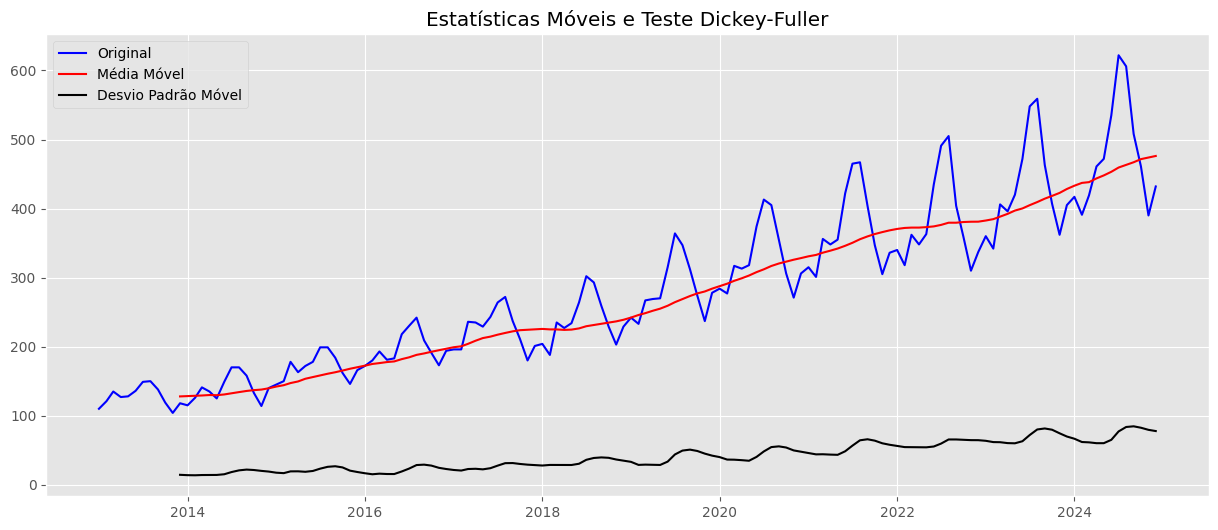


Resultado do Teste Dickey-Fuller:
Estatística do Teste              0.809204
Valor-p                           0.991783
Número de Lags Consideradas      13.000000
Número de Observações Usadas    130.000000
Valor Crítico (1%)               -3.481682
Valor Crítico (5%)               -2.884042
Valor Crítico (10%)              -2.578770
dtype: float64

Conclusão:
O valor-p é maior que 0.05 e, portanto, não temos evidências para rejeitar a hipótese nula.
Essa série provavelmente não é estacionária.


In [22]:
# Executando nossa função
fn_testa_estacionaridade(dados_serie)

In [23]:
%reload_ext watermark
%watermark -a "robertossoares-lflnglrnng"

Author: robertossoares-lflnglrnng



In [24]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.4.0

Compiler    : MSC v.1943 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 158 Stepping 9, GenuineIntel
CPU cores   : 4
Architecture: 64bit



In [25]:
%watermark --iversions

matplotlib : 3.10.3
numpy      : 2.3.1
pandas     : 2.3.1
seaborn    : 0.13.2
statsmodels: 0.14.5



<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>

In [28]:
#!pip install nbconvert -U -q
!jupyter nbconvert p01-etapa02.ipynb --to html --template D:/_jupyter/my-template-html-v07.tpl

[NbConvertApp] Converting notebook p01-etapa02.ipynb to html
[NbConvertApp] Writing 783421 bytes to p01-etapa02.html
